# 01. Drug Consumption DNN - Data Preparation & Training

## Prediksi Risiko Konsumsi Narkoba Menggunakan Deep Neural Network

**Author:** Muhammad Ichsan Junaedi & Amanda Wijayanti  
**Institution:** STMIK TAZKIA  
**Date:** December 2024

---

### Objectives (Tujuan)
1. Load & preprocess Drug Consumption dataset dari UCI
2. Membangun model Deep Neural Network (DNN) baseline
3. Melakukan Hyperparameter tuning dengan Keras Tuner untuk mencari model terbaik
4. Menyimpan model terbaik untuk evaluasi selanjutnya

## 1. Environment Setup

In [3]:
# Menghilangkan peringatan (warnings) agar output lebih bersih
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Library Standar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
from datetime import datetime
import time

# Deep Learning (TensorFlow & Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# Keras Tuner (Untuk mencari hyperparameter otomatis)
import keras_tuner as kt

# Sklearn (Untuk preprocessing dan metrik)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

# Konfigurasi
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Gaya Plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Definisi Path (Lokasi Folder)
PATHS = {
    'raw_data': '../data/raw/',
    'processed_data': '../data/processed/',
    'models': '../models/',
    'results': '../results/metrics/',
    'figures': '../results/figures/'
}

# Membuat folder jika belum ada
for path in PATHS.values():
    os.makedirs(path, exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"Keras Tuner: {kt.__version__}")
print(f"Random Seed: {RANDOM_SEED}")

TensorFlow: 2.20.0
Keras Tuner: 1.4.8
Random Seed: 42


## 2. Data Loading & Preprocessing

In [4]:
# Memuat dataset mentah
try:
    df = pd.read_csv(PATHS['raw_data'] + 'drug_consumption_raw.csv')
    print("Dataset berhasil dimuat.")
except FileNotFoundError:
    # Fallback jika file tidak ditemukan di folder raw, coba di folder notebook
    if os.path.exists('drug_consumption_raw.csv'):
        df = pd.read_csv('drug_consumption_raw.csv')
        print("Dataset dimuat dari direktori saat ini.")
    else:
        print("ERROR: File dataset tidak ditemukan!")

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"Shape: {df.shape}")
print(f"Samples: {df.shape[0]:,}")
print(f"Features: {df.shape[1]}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

df.head()

Dataset berhasil dimuat.
DATASET OVERVIEW
Shape: (1885, 32)
Samples: 1,885
Features: 32

Missing values: 0
Duplicates: 0


,ID,age,gender,education,country,ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [5]:
# Definisi kelompok kolom
demographic_cols = ['age', 'gender', 'education', 'country', 'ethnicity']
personality_cols = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore']
behavioral_cols = ['Impulsive', 'SS']

# Daftar obat ilegal untuk target biner
illegal_drugs = ['Amphet', 'Amyl', 'Benzos', 'Cannabis', 'Coke', 'Crack',
                 'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD',
                 'Meth', 'Mushrooms', 'Semer', 'VSA']

# Membuat target biner: User (1) jika menggunakan obat ilegal minimal satu kali dalam setahun terakhir (CL3-CL6)
def create_binary_target(row):
    for drug in illegal_drugs:
        if drug in row.index:
            if row[drug] in ['CL3', 'CL4', 'CL5', 'CL6']:
                return 1
    return 0

df['drug_user'] = df.apply(create_binary_target, axis=1)

print("\n" + "="*70)
print("DISTRIBUSI TARGET BINARY")
print("="*70)
print(df['drug_user'].value_counts())
print(f"\nRasio Kelas: {df['drug_user'].value_counts()[0]/df['drug_user'].value_counts()[1]:.2f}:1")


DISTRIBUSI TARGET BINARY
drug_user
1    1179
0     706
Name: count, dtype: int64

Rasio Kelas: 0.60:1


In [6]:
# Preprocessing Fitur

# Memilih kolom fitur yang akan digunakan (Demografi + Kepribadian + Perilaku)
feature_cols = demographic_cols + personality_cols + behavioral_cols

# Cek apakah data yang sudah diproses ada? Jika tidak, buat baru.
if os.path.exists(PATHS['processed_data'] + 'X_train.csv'):
    print("Memuat data yang sudah diproses sebelumnya...")
    X_train = pd.read_csv(PATHS['processed_data'] + 'X_train.csv')
    y_train = pd.read_csv(PATHS['processed_data'] + 'y_train.csv').values.ravel()
    X_test = pd.read_csv(PATHS['processed_data'] + 'X_test.csv')
    y_test = pd.read_csv(PATHS['processed_data'] + 'y_test.csv').values.ravel()
else:
    print("Membuat split train-test baru...")
    # Gunakan fitur numerik asli
    X = df[feature_cols].copy()
    y = df['drug_user'].values
    
    # Pisahkan data latih (train) dan uji (test) dengan proporsi 80:20
    # Stratify=y memastikan proporsi kelas user/non-user seimbang di kedua set
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    
    # Simpan data yang sudah diproses
    X_train.to_csv(PATHS['processed_data'] + 'X_train.csv', index=False)
    X_test.to_csv(PATHS['processed_data'] + 'X_test.csv', index=False)
    pd.DataFrame(y_train).to_csv(PATHS['processed_data'] + 'y_train.csv', index=False)
    pd.DataFrame(y_test).to_csv(PATHS['processed_data'] + 'y_test.csv', index=False)

print(f"\nSampel Latih: {len(X_train):,}")
print(f"Sampel Uji: {len(X_test):,}")
print(f"Fitur: {X_train.shape[1]}")

Membuat split train-test baru...

Sampel Latih: 1,508
Sampel Uji: 377
Fitur: 12


In [7]:
# Penskalaan Fitur (Scaling) - SANGAT PENTING untuk Neural Networks
# StandardScaler mengubah data sehingga memiliki mean=0 dan std=1
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Simpan scaler agar bisa dipakai nanti
with open(PATHS['models'] + 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Penskalaan fitur selesai.")
print(f"Mean Train (harus mendekati 0): {X_train_scaled.mean().mean():.4f}")
print(f"Std Train (harus mendekati 1): {X_train_scaled.std().mean():.4f}")

Penskalaan fitur selesai.
Mean Train (harus mendekati 0): 0.0000
Std Train (harus mendekati 1): 1.0003


## 3. DNN Baseline Model

In [8]:
def build_baseline_dnn(input_dim, learning_rate=0.001):
    """
    Model DNN Baseline: Arsitektur sederhana.
    Layer: 128 -> 64 -> 32 -> 16 node dengan Dropout untuk mencegah overfitting.
    """
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim, name='dense_1'),
        Dropout(0.3, name='dropout_1'),
        Dense(64, activation='relu', name='dense_2'),
        Dropout(0.3, name='dropout_2'),
        Dense(32, activation='relu', name='dense_3'),
        Dropout(0.2, name='dropout_3'),
        Dense(16, activation='relu', name='dense_4'),
        Dropout(0.2, name='dropout_4'),
        Dense(1, activation='sigmoid', name='output')  # Output 1 node (Binary Classification)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Membangun model baseline
baseline_model = build_baseline_dnn(input_dim=X_train_scaled.shape[1])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Callbacks (Fungsi bantuan saat training)
callbacks = [
    # Berhenti jika tidak validasi tidak membaik setelah 20 epoch
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    # Kurangi learning rate jika stuck
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1),
    # Simpan model terbaik
    ModelCheckpoint(
        filepath=PATHS['models'] + 'dnn_baseline.h5',
        monitor='val_auc', save_best_only=True, verbose=1, mode='max'
    )
]

# Train baseline model
print("\n" + "="*70)
print("TRAINING BASELINE DNN")
print("="*70)

start_time = datetime.now()

history = baseline_model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

training_time = (datetime.now() - start_time).total_seconds()
print(f"\nTraining selesai dalam {training_time:.2f} detik.")

# Simpan riwayat training
with open(PATHS['models'] + 'dnn_baseline_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)


TRAINING BASELINE DNN
Epoch 1/150
33/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5137 - auc: 0.5552 - loss: 0.6943 
Epoch 1: val_auc improved from None to 0.86685, saving model to ../models/dnn_baseline.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6095 - auc: 0.6532 - loss: 0.6444 - val_accuracy: 0.7914 - val_auc: 0.8668 - val_loss: 0.4941 - learning_rate: 0.0010
Epoch 2/150
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7559 - auc: 0.8540 - loss: 0.4962 
Epoch 2: val_auc improved from 0.86685 to 0.88210, saving model to ../models/dnn_baseline.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7836 - auc: 0.8681 - loss: 0.4570 - val_accuracy: 0.8179 - val_auc: 0.8821 - val_loss: 0.4000 - learning_rate: 0.0010
Epoch 3/150
 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8438 - auc: 0.9141 - loss: 0.4113
Epoch 3: val_auc improved from 0.88210 to 0.89211, saving model to ../models/dnn_baseline.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8134 - auc: 0.8812 - loss: 0.4221 - val_accuracy: 0.8344 - val_auc: 0.8921 - val_loss: 0.3937 - learning_rate: 0.0010
Epoch 4/150
 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7812 - auc: 0.9004 - loss: 0.5126
Epoch 4: val_auc did not improve from 0.89211
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8300 - auc: 0.8925 - loss: 0.4001 - val_accuracy: 0.8377 - val_auc: 0.8920 - val_loss: 0.3934 - learning_rate: 0.0010
Epoch 5/150
23/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8335 - auc: 0.9052 - loss: 0.3958 
Epoch 5: val_auc did not improve from 0.89211
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8209 - auc: 0.8954 - loss: 0.3945 - val_accuracy: 0.8245 - val_auc: 0.8903 - val_loss: 0.3944 - learning_rate: 0.0010
Epoch 6/150
32/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8510 - auc: 0.9106 - loss: 0.3875 
Epoch 6: val_auc did not improve from 0.89211
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8333 - auc: 0.8994 - loss: 0.3957 - val_accuracy: 0.8146 - val_auc: 0.8935 - val_loss: 0.3880 - learning_rate: 0.0010
Epoch 9/150
29/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8297 - auc: 0.9013 - loss: 0.4034 
Epoch 9: val_auc did not improve from 0.89346
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8342 - auc: 0.9037 - loss: 0.3856 - val_accuracy: 0.8245 - val_auc: 0.8915 - val_loss: 0.3946 - learning_rate: 0.0010
Epoch 10/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8371 - auc: 0.9125 - loss: 0.3803 
Epoch 10: val_auc did not improve from 0.89346
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8308 - auc: 0.9081 - loss: 0.3743 - val_accuracy: 0.8212 - val_auc: 0.8916 - val_loss: 0.3923 - learning_rate: 0.0010
Epoch 11/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8456 - auc: 0.9145 - loss: 0.3841 
Epoch 11: val_auc did not improve from 0.89346
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accu

In [10]:
# Evaluasi model baseline
best_baseline = load_model(PATHS['models'] + 'dnn_baseline.h5')

# Prediksi
y_pred_proba = best_baseline.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metrik
baseline_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_pred_proba),
    'f1_score': f1_score(y_test, y_pred)
}

print("\n" + "="*70)
print("HASIL BASELINE DNN")
print("="*70)
print(f"Accuracy: {baseline_metrics['accuracy']:.4f}")
print(f"ROC-AUC:  {baseline_metrics['roc_auc']:.4f}")
print(f"F1-Score: {baseline_metrics['f1_score']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-User', 'User']))

# Simpan metrik baseline
with open(PATHS['results'] + 'dnn_baseline_metrics.json', 'w') as f:
    json.dump({'test_metrics': baseline_metrics}, f, indent=4)


HASIL BASELINE DNN
Accuracy: 0.8382
ROC-AUC:  0.9082
F1-Score: 0.8688

Classification Report:
              precision    recall  f1-score   support

    Non-User       0.77      0.81      0.79       141
        User       0.88      0.86      0.87       236

    accuracy                           0.84       377
   macro avg       0.83      0.83      0.83       377
weighted avg       0.84      0.84      0.84       377



## 4. Hyperparameter Tuning

In [11]:
def build_tunable_model(hp):
    """
    Membangun model DNN dengan hyperparameter yang bisa di-tune (diubah-ubah otomatis).
    
    Ruang Pencarian (Search Space):
    - Arsitektur: jumlah neuron per layer, jumlah layer
    - Regularisasi: tingkat dropout, L2 penalty, penggunaan batch normalization
    - Optimasi: learning rate, jenis optimizer (Adam vs RMSprop)
    """
    model = Sequential()
    
    # Layer 1 (Wajib)
    model.add(Dense(
        units=hp.Choice('units_layer_1', values=[64, 128, 256]),
        activation='relu',
        input_dim=X_train_scaled.shape[1],
        kernel_regularizer=l2(hp.Choice('l2_reg', values=[0.0001, 0.001, 0.01]))
    ))
    
    if hp.Boolean('batch_norm_1'):
        model.add(BatchNormalization())
    
    model.add(Dropout(hp.Choice('dropout_1', values=[0.2, 0.3, 0.4])))
    
    # Layer 2 (Wajib)
    model.add(Dense(
        units=hp.Choice('units_layer_2', values=[32, 64, 128]),
        activation='relu'
    ))
    
    if hp.Boolean('batch_norm_2'):
        model.add(BatchNormalization())
    
    model.add(Dropout(hp.Choice('dropout_2', values=[0.2, 0.3, 0.4])))
    
    # Layer 3 (Wajib)
    model.add(Dense(
        units=hp.Choice('units_layer_3', values=[16, 32, 64]),
        activation='relu'
    ))
    model.add(Dropout(hp.Choice('dropout_3', values=[0.1, 0.2, 0.3])))
    
    # Optional Layer 4 (Bisa ada bisa tidak)
    if hp.Boolean('use_layer_4'):
        model.add(Dense(
            units=hp.Choice('units_layer_4', values=[8, 16, 32]),
            activation='relu'
        ))
        model.add(Dropout(hp.Choice('dropout_4', values=[0.1, 0.2, 0.3])))
    
    # Output Layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Optimizer
    optimizer_name = hp.Choice('optimizer', values=['adam', 'rmsprop'])
    learning_rate = hp.Choice('learning_rate', values=[0.0001, 0.0005, 0.001, 0.005])
    
    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    else:
        optimizer = RMSprop(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model

print("Model Tuner builder defined.")

Model Tuner builder defined.


In [12]:
# Inisialisasi Keras Tuner
tuner = kt.RandomSearch(
    hypermodel=build_tunable_model,
    objective=kt.Objective('val_auc', direction='max'), # Kita ingin maksimalkan AUC
    max_trials=50, # Coba 50 kombinasi berbeda
    executions_per_trial=1,
    directory=PATHS['models'] + 'keras_tuner',
    project_name='dnn_drug_prediction',
    overwrite=False,
    seed=RANDOM_SEED
)

# Callbacks Tuning
tuning_callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=0)
]

print("\n" + "="*70)
print("HYPERPARAMETER TUNING")
print("="*70)
print("Strategi: RandomSearch")
print("Maksimal Percobaan: 50")
print("Tujuan: Maksimalkan val_auc")


HYPERPARAMETER TUNING
Strategi: RandomSearch
Maksimal Percobaan: 50
Tujuan: Maksimalkan val_auc


In [13]:
# Jalankan pencarian hyperparameter
print("\nMemulai pencarian hyperparameter...")
print("(Proses ini bisa memakan waktu 10-30 menit tergantung hardware)\n")

start_time = time.time()

tuner.search(
    X_train_scaled,
    y_train,
    epochs=150,
    validation_split=0.2,
    callbacks=tuning_callbacks,
    verbose=1
)

search_time = time.time() - start_time
print(f"\nPencarian selesai dalam {search_time/60:.2f} menit.")

Trial 50 Complete [00h 00m 07s]
val_auc: 0.8956081867218018

Best val_auc So Far: 0.9016856551170349
Total elapsed time: 00h 11m 57s

Pencarian selesai dalam 11.94 menit.


In [14]:
# Ambil hyperparameter terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "="*70)
print("HYPERPARAMETERS TERBAIK DITEMUKAN")
print("="*70)
print(f"\nArchitecture:")
print(f"  Layer 1: {best_hps.get('units_layer_1')} units")
print(f"  Layer 2: {best_hps.get('units_layer_2')} units")
print(f"  Layer 3: {best_hps.get('units_layer_3')} units")
if best_hps.get('use_layer_4'):
    print(f"  Layer 4: {best_hps.get('units_layer_4')} units")
else:
    print(f"  Layer 4: Not used")

print(f"\nRegularization:")
print(f"  L2: {best_hps.get('l2_reg')}")
print(f"  Dropout 1: {best_hps.get('dropout_1')}")
print(f"  Dropout 2: {best_hps.get('dropout_2')}")
print(f"  Dropout 3: {best_hps.get('dropout_3')}")
print(f"  BatchNorm 1: {best_hps.get('batch_norm_1')}")
print(f"  BatchNorm 2: {best_hps.get('batch_norm_2')}")

print(f"\nOptimization:")
print(f"  Optimizer: {best_hps.get('optimizer')}")
print(f"  Learning Rate: {best_hps.get('learning_rate')}")

# Simpan hyperparameter terbaik ke file JSON
best_hp_dict = {key: best_hps.get(key) for key in best_hps.values.keys()}
with open(PATHS['results'] + 'best_hyperparameters.json', 'w') as f:
    json.dump(best_hp_dict, f, indent=4)


HYPERPARAMETERS TERBAIK DITEMUKAN

Architecture:
  Layer 1: 256 units
  Layer 2: 32 units
  Layer 3: 64 units
  Layer 4: 8 units

Regularization:
  L2: 0.0001
  Dropout 1: 0.4
  Dropout 2: 0.4
  Dropout 3: 0.3
  BatchNorm 1: False
  BatchNorm 2: True

Optimization:
  Optimizer: rmsprop
  Learning Rate: 0.005


In [15]:
# Bangun dan latih model final dengan hyperparameter terbaik
print("\n" + "="*70)
print("TRAINING MODEL FINAL (OPTIMIZED)")
print("="*70)

best_model = tuner.hypermodel.build(best_hps)

final_callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1),
    # Simpan model final ini sebagai 'dnn_tuned.h5'
    ModelCheckpoint(
        filepath=PATHS['models'] + 'dnn_tuned.h5',
        monitor='val_auc', save_best_only=True, verbose=1, mode='max'
    )
]

tuned_history = best_model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=final_callbacks,
    verbose=1
)

# Simpan history tuned
with open(PATHS['models'] + 'dnn_tuned_history.pkl', 'wb') as f:
    pickle.dump(tuned_history.history, f)

print("\nFinal model training completed.")


TRAINING MODEL FINAL (OPTIMIZED)
Epoch 1/150
33/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6758 - auc: 0.7519 - loss: 0.5692
Epoch 1: val_auc improved from None to 0.87823, saving model to ../models/dnn_tuned.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7405 - auc: 0.8175 - loss: 0.5228 - val_accuracy: 0.7980 - val_auc: 0.8782 - val_loss: 0.4275 - learning_rate: 0.0050
Epoch 2/150
34/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8112 - auc: 0.8685 - loss: 0.4547 
Epoch 2: val_auc improved from 0.87823 to 0.88993, saving model to ../models/dnn_tuned.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7993 - auc: 0.8702 - loss: 0.4413 - val_accuracy: 0.8179 - val_auc: 0.8899 - val_loss: 0.4086 - learning_rate: 0.0050
Epoch 3/150
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7909 - auc: 0.8812 - loss: 0.4582 
Epoch 3: val_auc improved from 0.88993 to 0.89261, saving model to ../models/dnn_tuned.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7935 - auc: 0.8794 - loss: 0.4453 - val_accuracy: 0.8146 - val_auc: 0.8926 - val_loss: 0.4036 - learning_rate: 0.0050
Epoch 4/150
34/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8185 - auc: 0.8795 - loss: 0.4505 
Epoch 4: val_auc did not improve from 0.89261
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8101 - auc: 0.8786 - loss: 0.4348 - val_accuracy: 0.8113 - val_auc: 0.8877 - val_loss: 0.4196 - learning_rate: 0.0050
Epoch 5/150
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8227 - auc: 0.8902 - loss: 0.4164 
Epoch 5: val_auc did not improve from 0.89261
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8126 - auc: 0.8856 - loss: 0.4153 - val_accuracy: 0.8146 - val_auc: 0.8871 - val_loss: 0.4395 - learning_rate: 0.0050
Epoch 6/150
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8266 - auc: 0.8957 - loss: 0.4226 
Epoch 6: val_auc did not improve from 0.89261
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [16]:
# Evaluasi model tuned
tuned_model = load_model(PATHS['models'] + 'dnn_tuned.h5')

# Prediksi
y_pred_proba_tuned = tuned_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_tuned = (y_pred_proba_tuned >= 0.5).astype(int)

# Metrik
tuned_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_tuned),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_tuned),
    'f1_score': f1_score(y_test, y_pred_tuned)
}

print("\n" + "="*70)
print("HASIL TUNED DNN")
print("="*70)
print(f"Accuracy: {tuned_metrics['accuracy']:.4f}")
print(f"ROC-AUC:  {tuned_metrics['roc_auc']:.4f}")
print(f"F1-Score: {tuned_metrics['f1_score']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Non-User', 'User']))

# Bandingkan dengan Baseline
print("\n" + "="*70)
print("PENINGKATAN vs BASELINE")
print("="*70)
for metric in ['accuracy', 'roc_auc', 'f1_score']:
    improvement = tuned_metrics[metric] - baseline_metrics[metric]
    print(f"{metric}: {improvement:+.4f} ({improvement*100:+.2f}%)")

# Simpan metrik tuned
with open(PATHS['results'] + 'dnn_tuned_metrics.json', 'w') as f:
    json.dump({'test_metrics': tuned_metrics}, f, indent=4)


HASIL TUNED DNN
Accuracy: 0.8382
ROC-AUC:  0.9088
F1-Score: 0.8653

Classification Report:
              precision    recall  f1-score   support

    Non-User       0.75      0.85      0.80       141
        User       0.90      0.83      0.87       236

    accuracy                           0.84       377
   macro avg       0.83      0.84      0.83       377
weighted avg       0.85      0.84      0.84       377


PENINGKATAN vs BASELINE
accuracy: +0.0000 (+0.00%)
roc_auc: +0.0006 (+0.06%)
f1_score: -0.0035 (-0.35%)


## 5. Training Visualization

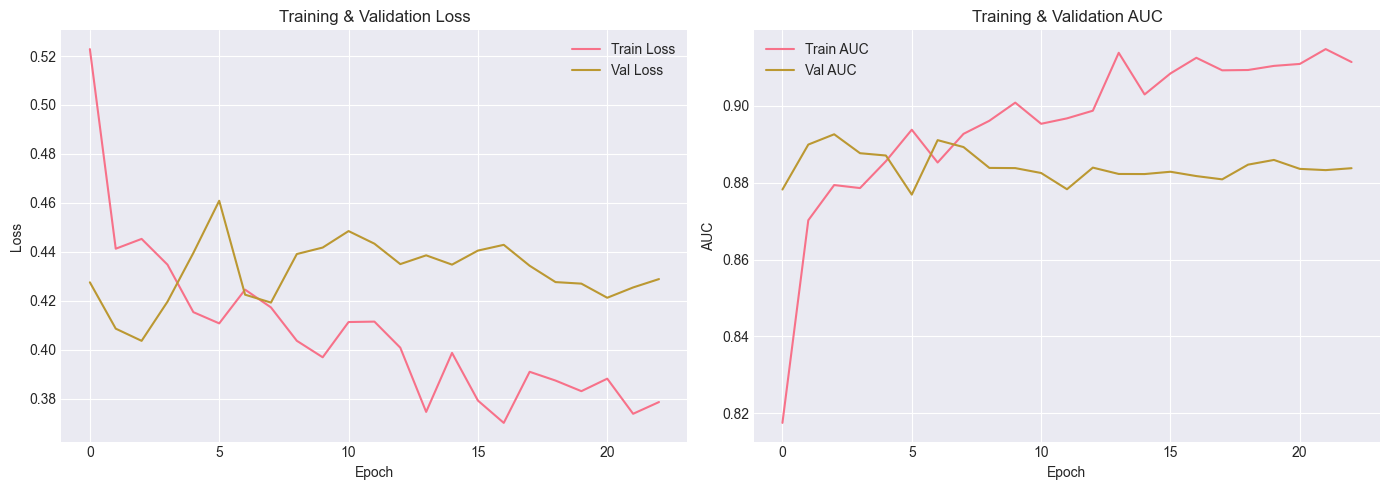


Visualisasi training disimpan.


In [18]:
# Plot kurva training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kurva Loss
axes[0].plot(tuned_history.history['loss'], label='Train Loss')
axes[0].plot(tuned_history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Kurva AUC
axes[1].plot(tuned_history.history['auc'], label='Train AUC')
axes[1].plot(tuned_history.history['val_auc'], label='Val AUC')
axes[1].set_title('Training & Validation AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig(PATHS['figures'] + 'dnn_tuned_training.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualisasi training disimpan.")

## 6. Summary

### Models Saved (Model yang disimpan):
- `models/dnn_baseline.h5` - Model DNN Baseline (awalan)
- `models/dnn_tuned.h5` - Model DNN Terbaik (hasil tuning)
- `models/scaler.pkl` - Scaler fitur (penting untuk data baru)

### Next Steps (Langkah Selanjutnya):
- Jalankan notebook `02_Evaluation_Comparison.ipynb` untuk evaluasi lengkap
- Bandingkan hasil dengan Random Forest dari UTS
- Analisis kepentingan fitur (feature importance) dengan SHAP

In [19]:
print("="*70)
print("NOTEBOOK 1 SELESAI")
print("="*70)
print(f"\nBaseline DNN - ROC-AUC: {baseline_metrics['roc_auc']:.4f}")
print(f"Tuned DNN - ROC-AUC: {tuned_metrics['roc_auc']:.4f}")
print(f"\nModel disimpan di: {PATHS['models']}")
print(f"Metrik disimpan di: {PATHS['results']}")
print("\nSilakan lanjut ke 02_Evaluation_Comparison.ipynb untuk analisis lengkap.")

NOTEBOOK 1 SELESAI

Baseline DNN - ROC-AUC: 0.9082
Tuned DNN - ROC-AUC: 0.9088

Model disimpan di: ../models/
Metrik disimpan di: ../results/metrics/

Silakan lanjut ke 02_Evaluation_Comparison.ipynb untuk analisis lengkap.
